In [1]:
from datetime import datetime

import finlab
import pandas as pd
import yaml
from finlab import data
from matplotlib import pyplot as plt

from evaluation.stats import sharpe, sharpe_0050
from strategies.get_result import get_result

finlab.login("ntSS3778pZi2FfkeYxXP0p+S0iI4AggkcphAUxh/lTVrWqT2FreKQsDkTA92CM7d#vip_m")

輸入成功!
輸入成功!


In [2]:
f = open("config/backtest.yaml")
cfg = yaml.safe_load(f)
result_dir = "results/Example_Result"

start_date = datetime.strptime("2025-06-01", "%Y-%m-%d")
end_date = datetime.strptime("2026-01-01", "%Y-%m-%d")

cfg["backtest_type"] = "daily" # "daily" or "allen" or "gino"
result = get_result(
    cfg,
    result_dir,
    start_date=start_date,
    end_date=end_date,
)

roi = result["model"].returns.iloc[-1] / result["model"].returns.iloc[0] - 1
print("ROI:", roi)
sharpe_ratio = sharpe(result["model"].returns)
print("Sharpe Ratio:", sharpe_ratio)

with data.universe("ETF"):
    close_df = data.get("etl:adj_close")
    close_df = close_df["0050"]
close_df = close_df[
    (close_df.index >= result["model"].returns.index[0])
    & (close_df.index <= result["model"].returns.index[-1])
]
etf_roi = close_df.iloc[-1] / close_df.iloc[0] - 1
print("0050 ROI:", etf_roi)
etf_sharpe = sharpe_0050(result["model"].returns, close_df)

Processing 20230103_20231229...
Processing 20220103_20221230...
Processing 20210104_20211230...
Processing 20250101_20260101...
Processing 20240102_20241231...


Your version is 1.2.20, please install a newer version.
Use "pip install finlab==1.5.7" to update the latest version.
148it [00:00, 345.62it/s]


ROI: 0.8988785201371907
Sharpe Ratio: 3.2269644786935485
0050 ROI: 0.5019741914381615


Sharpe(0050) Ratio: 1.4536266385660026


<Axes: title={'center': 'Backtest Strategy Returns'}, xlabel='date'>

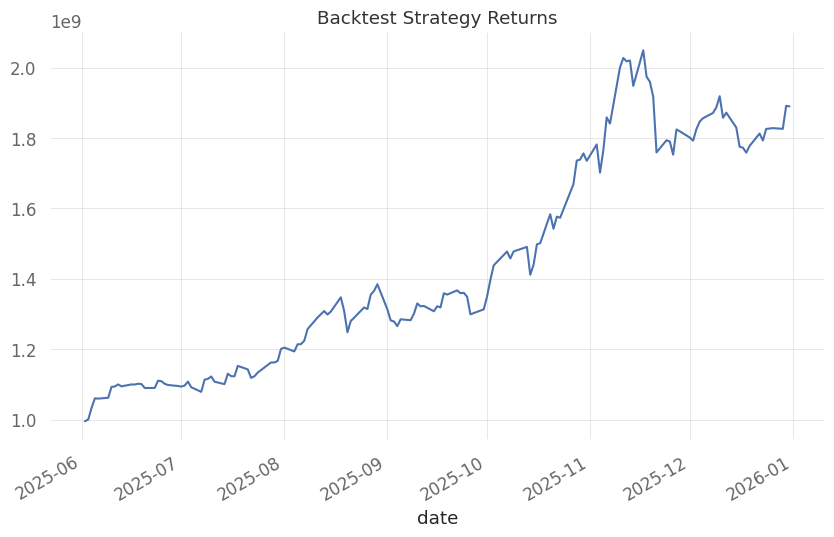

In [3]:
print("Sharpe(0050) Ratio:", etf_sharpe)
result["model"].returns.plot(title="Backtest Strategy Returns")

Mean Invest Ratio: 0.8218644739178137


<Axes: title={'center': 'Backtest Strategy Invest Ratio'}, xlabel='date'>

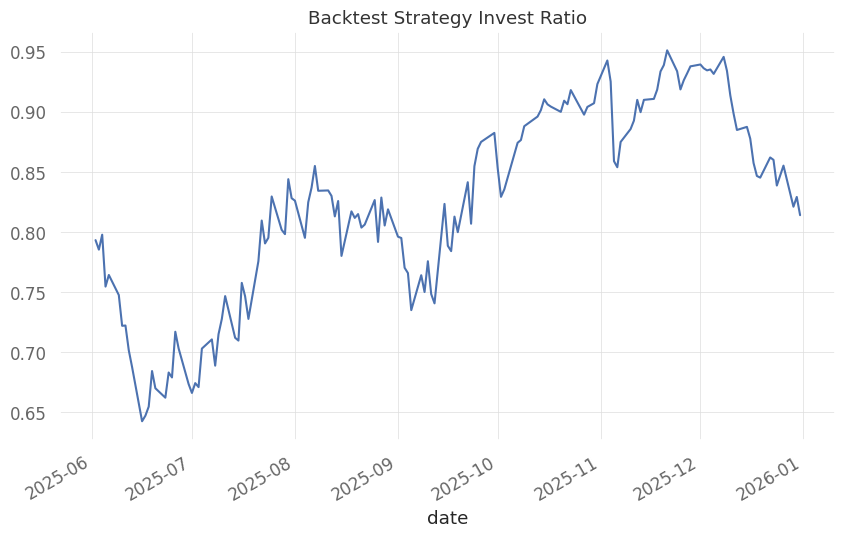

In [4]:
print("Mean Invest Ratio:", result["model"].invest_ratio.mean())
result["model"].invest_ratio.plot(title="Backtest Strategy Invest Ratio")

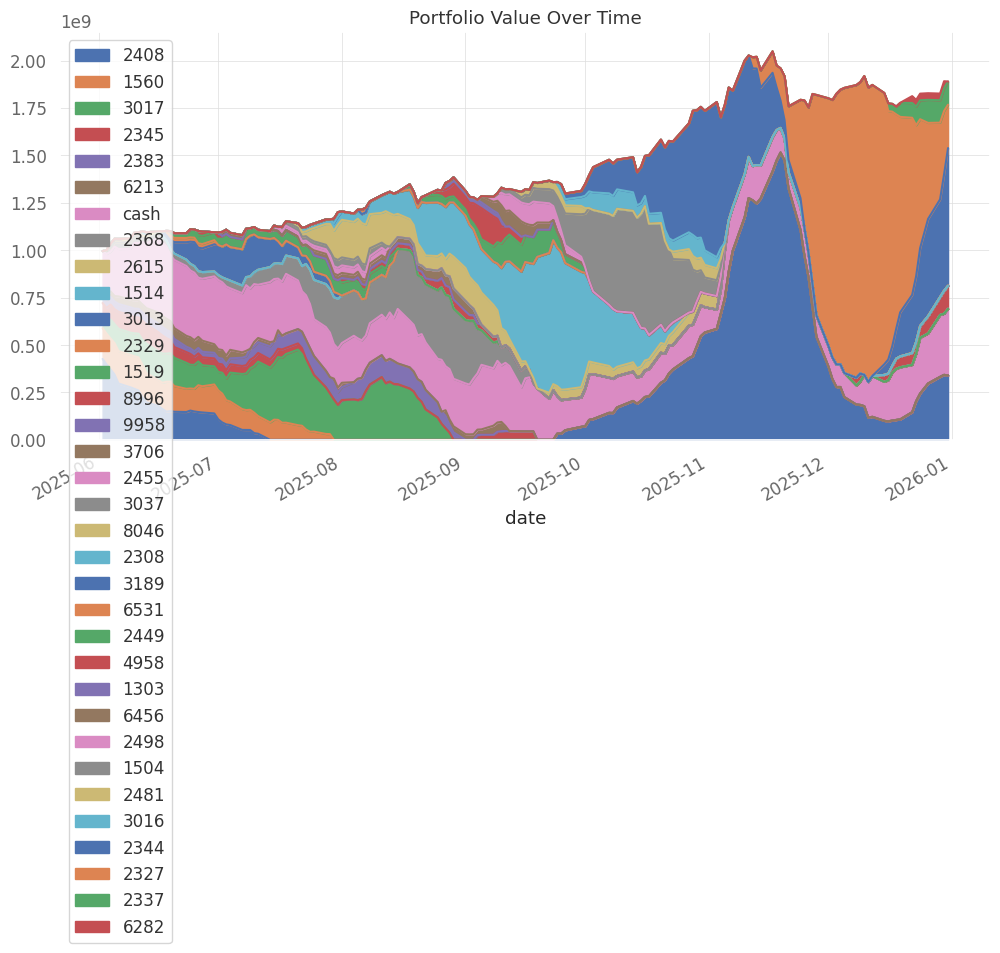

In [5]:
portfolio_value = result["model"].portfolio_value.fillna(0)
portfolio_value.plot(title="Portfolio Value Over Time", figsize=(12, 6), stacked=True, kind='area')
plt.legend(loc='upper left')

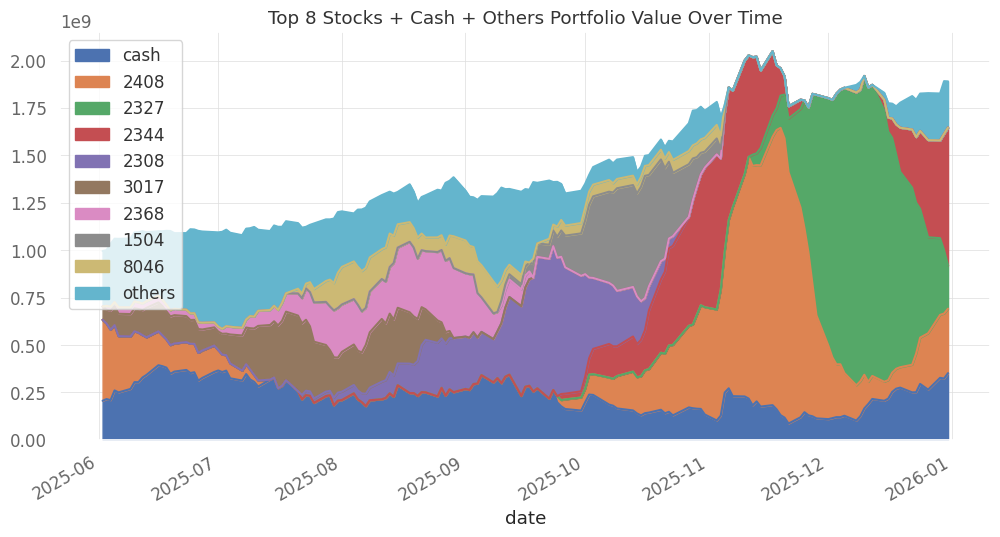

In [6]:
top_n = 8
top_stocks = (
    portfolio_value.drop(columns=["cash"])
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

simplified_portfolio_value = portfolio_value[["cash"]]
simplified_portfolio_value[top_stocks] = portfolio_value[top_stocks]
simplified_portfolio_value["others"] = portfolio_value.drop(
    columns=top_stocks.tolist() + ["cash"]
).sum(axis=1)

simplified_portfolio_value.plot(
    title=f"Top {top_n} Stocks + Cash + Others Portfolio Value Over Time",
    figsize=(12, 6),
    stacked=True,
    kind="area",
    legend=True,
)
plt.legend(loc="upper left")